### GCRL implementation - Four Rooms GridWorld


In [70]:
import numpy as np
import torch
import gymnasium as gym
from gymnasium import spaces
from dataclasses import dataclass


class FourRoomsGridWorld(gym.Env):

    metadata = {"render_modes": ["rgb_array"], "render_fps": 8}

    def __init__(self, room_size=11, render_mode=None, max_episode_steps=500):
        super().__init__()
        self.room_size = int(room_size)
        self.grid_size = (self.room_size * 2) + 1
        self.render_mode = render_mode
        self.max_episode_steps = int(max_episode_steps)

        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(2,), dtype=np.float32)
        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0], dtype=np.float32),
            high=np.array([self.grid_size - 1.0, self.grid_size - 1.0], dtype=np.float32),
            shape=(2,),
            dtype=np.float32,
        )

        mid_point = (self.room_size - 1) // 2
        self._door_coords = {
            (self.room_size, mid_point),
            (self.room_size, self.room_size + mid_point + 1),
            (mid_point, self.room_size),
            (self.room_size + mid_point + 1, self.room_size),
        }

        self._blocked_cells = self._build_walls()
        self._outer_wall_cells = self._build_outer_walls()
        self._agent_pos = np.array([0, 0], dtype=np.int32)
        self._goal_pos = None
        self._step_count = 0

    def _build_walls(self):
        wall = self.room_size
        blocked = set()
        for y in range(self.grid_size):
            if (wall, y) not in self._door_coords:
                blocked.add((wall, y))
        for x in range(self.grid_size):
            if (x, wall) not in self._door_coords:
                blocked.add((x, wall))
        return blocked

    def _build_outer_walls(self):
        outer = set()
        boundary_min = -1
        boundary_max = self.grid_size
        for y in range(boundary_min, boundary_max + 1):
            outer.add((boundary_min, y))
            outer.add((boundary_max, y))
        for x in range(boundary_min, boundary_max + 1):
            outer.add((x, boundary_min))
            outer.add((x, boundary_max))
        return outer

    def _is_valid_cell(self, cell):
        x, y = int(cell[0]), int(cell[1])
        if x < 0 or y < 0 or x >= self.grid_size or y >= self.grid_size:
            return False
        return (x, y) not in self._blocked_cells

    def sample_initial_state(self):
        while True:
            sample = self.np_random.integers(0, 3, size=(2,), dtype=np.int32)
            if self._is_valid_cell(sample):
                return sample

    def set_goal_position(self, goal_position):
        goal = np.asarray(goal_position, dtype=np.int32)
        if goal.shape != (2,) or not self._is_valid_cell(goal):
            raise ValueError(f"Invalid goal position: {goal_position}")
        self._goal_pos = goal

    def _obs(self):
        return self._agent_pos.astype(np.float32)

    def _action_to_delta(self, action):
        a = np.asarray(action, dtype=np.float32).reshape(-1)
        if a.shape[0] != 2:
            raise ValueError(f"Expected action shape (2,), got {a.shape}")
        if abs(a[0]) >= abs(a[1]):
            dx = int(np.sign(a[0]))
            dy = 0
        else:
            dx = 0
            dy = int(np.sign(a[1]))
        return np.array([dx, dy], dtype=np.int32)

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        options = options or {}
        start = options.get("start_position")
        if start is None:
            start = self.sample_initial_state()
        else:
            start = np.asarray(start, dtype=np.int32)
        if not self._is_valid_cell(start):
            raise ValueError(f"Invalid start position: {tuple(start.tolist())}")
        self._agent_pos = start.copy()
        self._step_count = 0
        return self._obs(), {}

    def step(self, action):
        delta = self._action_to_delta(action)
        candidate = self._agent_pos + delta
        if self._is_valid_cell(candidate):
            self._agent_pos = candidate

        self._step_count += 1
        truncated = self._step_count >= self.max_episode_steps
        return self._obs(), 0.0, False, truncated, {}

    def _render_rgb(self):
        scale = 20
        canvas = np.full((self.grid_size + 2, self.grid_size + 2, 3), 255, dtype=np.uint8)

        for (x, y) in self._outer_wall_cells:
            canvas[y + 1, x + 1] = np.array([30, 30, 30], dtype=np.uint8)

        for (x, y) in self._blocked_cells:
            canvas[y + 1, x + 1] = np.array([30, 30, 30], dtype=np.uint8)

        if self._goal_pos is not None:
            gx, gy = self._goal_pos
            canvas[gy + 1, gx + 1] = np.array([50, 180, 50], dtype=np.uint8)

        ax, ay = self._agent_pos
        canvas[ay + 1, ax + 1] = np.array([220, 40, 40], dtype=np.uint8)
        return np.kron(canvas, np.ones((scale, scale, 1), dtype=np.uint8))

    def render(self):
        if self.render_mode != "rgb_array":
            return None
        return self._render_rgb()


class FourRoomsGoalWrapper(gym.Wrapper):
    """Sparse-reward goal wrapper with configurable goal and slight stochasticity."""

    def __init__(self, env, goal_position=(16, 16), goal_reward=1.0, step_reward=0.0, slip_prob=0.10):
        super().__init__(env)
        self.goal_reward = float(goal_reward)
        self.step_reward = float(step_reward)
        self.slip_prob = float(np.clip(slip_prob, 0.0, 1.0))
        self.goal_position = self._validate_goal(goal_position)
        self._sync_goal_to_env()

    def _validate_goal(self, goal_position):
        goal = np.asarray(goal_position, dtype=np.int32)
        if goal.shape != (2,) or not self.env._is_valid_cell(goal):
            raise ValueError(f"Invalid goal position: {goal_position}")
        return goal

    def _sync_goal_to_env(self):
        if hasattr(self.env, "set_goal_position"):
            self.env.set_goal_position(self.goal_position)
        else:
            self.env._goal_pos = self.goal_position.copy()

    def set_goal_position(self, goal_position):
        self.goal_position = self._validate_goal(goal_position)
        self._sync_goal_to_env()

    def _sample_slip_action(self):
        directions = np.array([[1, 0], [-1, 0], [0, 1], [0, -1]], dtype=np.float32)
        idx = int(self.env.np_random.integers(0, len(directions)))
        return directions[idx]

    def reset(self, *, seed=None, options=None):
        options = options or {}
        if "goal_position" in options:
            self.set_goal_position(options["goal_position"])
        obs, info = self.env.reset(seed=seed, options=options)
        self._sync_goal_to_env()
        info = dict(info)
        info["goal_position"] = self.goal_position.astype(np.int32).tolist()
        return obs, info

    def step(self, action):
        slipped = bool(self.env.np_random.random() < self.slip_prob)
        effective_action = self._sample_slip_action() if slipped else action
        obs, _, _, truncated, info = self.env.step(effective_action)

        at_goal = bool(np.array_equal(obs.astype(np.int32), self.goal_position))
        reward = self.goal_reward if at_goal else self.step_reward

        info = dict(info)
        info["slipped"] = slipped
        info["goal_position"] = self.goal_position.astype(np.int32).tolist()
        return obs, reward, at_goal, truncated, info


@dataclass # typed container for batches of replay data
class ReplayBatch:
    obs: torch.Tensor
    actions: torch.Tensor
    rewards: torch.Tensor
    next_obs: torch.Tensor
    terminated: torch.Tensor
    truncated: torch.Tensor
    episode_id: torch.Tensor
    timestep: torch.Tensor
    indices: torch.Tensor

    def __len__(self):
        return self.obs.shape[0]


class TrajectoryReplayBuffer:
    def __init__(self, capacity, obs_dim, action_dim, device="cpu"):
        self.capacity = capacity
        self.obs_dim = obs_dim
        self.action_dim = action_dim
        self.device = device

        self.obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, action_dim), dtype=np.float32)
        self.rewards = np.zeros((capacity, 1), dtype=np.float32)
        self.next_obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.terminated = np.zeros((capacity, 1), dtype=np.float32)
        self.truncated = np.zeros((capacity, 1), dtype=np.float32)

        self.episode_id = np.full((capacity,), -1, dtype=np.int64)
        self.timestep = np.full((capacity,), -1, dtype=np.int64)

        self.pos = 0
        self.size = 0
        self.full = False

        self.current_episode_id = 0
        self.episode_to_indices = {}

    def __len__(self):
        return self.size

    def add_episode(self, episode):
        ep_id = self.current_episode_id
        self.current_episode_id += 1

        ep_indices = []

        T = len(episode["obs"])
        for t in range(T):
            idx = self.pos

            if self.full:
                old_ep = self.episode_id[idx]
                if old_ep in self.episode_to_indices:
                    try:
                        self.episode_to_indices[old_ep].remove(idx)
                        if len(self.episode_to_indices[old_ep]) == 0:
                            del self.episode_to_indices[old_ep]
                    except ValueError:
                        pass

            self.obs[idx] = np.asarray(episode["obs"][t], dtype=np.float32)
            self.actions[idx] = np.asarray(episode["actions"][t], dtype=np.float32).reshape(-1)
            self.rewards[idx] = np.asarray([episode["rewards"][t]], dtype=np.float32)
            self.next_obs[idx] = np.asarray(episode["next_obs"][t], dtype=np.float32)
            self.terminated[idx] = np.asarray([episode["terminated"][t]], dtype=np.float32)
            self.truncated[idx] = np.asarray([episode["truncated"][t]], dtype=np.float32)

            self.episode_id[idx] = ep_id
            self.timestep[idx] = t

            ep_indices.append(idx)

            self.pos = (self.pos + 1) % self.capacity
            if self.size < self.capacity:
                self.size += 1
            else:
                self.full = True

        self.episode_to_indices[ep_id] = ep_indices

    def sample(self, batch_size):
        assert self.size > 0, "Buffer is empty"
        idxs = np.random.randint(0, self.size, size=batch_size)

        return ReplayBatch(
            obs=torch.tensor(self.obs[idxs], device=self.device),
            actions=torch.tensor(self.actions[idxs], device=self.device),
            rewards=torch.tensor(self.rewards[idxs], device=self.device),
            next_obs=torch.tensor(self.next_obs[idxs], device=self.device),
            terminated=torch.tensor(self.terminated[idxs], device=self.device),
            truncated=torch.tensor(self.truncated[idxs], device=self.device),
            episode_id=torch.tensor(self.episode_id[idxs], device=self.device),
            timestep=torch.tensor(self.timestep[idxs], device=self.device),
            indices=torch.tensor(idxs, device=self.device),
        )

    def sample_future_goal_batch(self, batch_size, min_k=1, max_k=None, gamma=0.99): # gamma controls the geometric distribution for positive-goal sampling
        assert self.size > 0, "Buffer is empty"

        valid_indices = []
        future_goal_indices = []

        tries = 0
        max_tries = batch_size * 20

        while len(valid_indices) < batch_size and tries < max_tries:
            idx = np.random.randint(0, self.size)
            ep_id = self.episode_id[idx]
            t = self.timestep[idx]

            if ep_id == -1 or ep_id not in self.episode_to_indices:
                tries += 1
                continue

            ep_idxs = self.episode_to_indices[ep_id]
            ep_len = len(ep_idxs)

            if t >= ep_len - 1:
                tries += 1
                continue

            max_valid_k = ep_len - 1 - t
            if max_k is not None:
                max_valid_k = min(max_valid_k, max_k)

            if max_valid_k < min_k:
                tries += 1
                continue

            geom_k = int(np.random.geometric(p=1.0 - gamma))  # k ~ Geometric(1-γ), matches sample_positive_future_goal
            k = max(min_k, min(geom_k, max_valid_k))  # clamp to [min_k, max_valid_k]
            future_t = t + k
            future_idx = ep_idxs[future_t]

            valid_indices.append(idx)
            future_goal_indices.append(future_idx)
            tries += 1

        assert len(valid_indices) > 0, "Could not sample valid future-goal pairs"

        idxs = np.array(valid_indices, dtype=np.int64)
        g_idxs = np.array(future_goal_indices, dtype=np.int64)

        batch = {
            "obs": torch.tensor(self.obs[idxs], device=self.device),
            "actions": torch.tensor(self.actions[idxs], device=self.device),
            "next_obs": torch.tensor(self.next_obs[idxs], device=self.device),
            "goals": torch.tensor(self.obs[g_idxs], device=self.device), # goals as the future state via GEOM
            "rewards": torch.tensor(self.rewards[idxs], device=self.device),
            "terminated": torch.tensor(self.terminated[idxs], device=self.device),
            "truncated": torch.tensor(self.truncated[idxs], device=self.device),
            "episode_id": torch.tensor(self.episode_id[idxs], device=self.device),
            "timestep": torch.tensor(self.timestep[idxs], device=self.device),
            "future_timestep": torch.tensor(self.timestep[g_idxs], device=self.device),
            "indices": torch.tensor(idxs, device=self.device),
            "goal_indices": torch.tensor(g_idxs, device=self.device),
        }
        return batch

    def sample_negative_future_goals(self, batch_size):
        idxs = np.random.randint(0, self.size, size=batch_size) # pick random indices from the buffer and indexing the observations
        return torch.tensor(self.obs[idxs], device=self.device)
    
    def sample_positive_future_goal(self, episode_index, timestep, k, gamma = 0.99):

        if episode_index not in self.episode_to_indices:
            raise ValueError(f"Episode index {episode_index} not found in buffer")

        ep_idxs = self.episode_to_indices[episode_index]
        ep_len = len(ep_idxs)

        if timestep >= ep_len - 1:
            raise ValueError(f"Timestep {timestep} is out of bounds for episode of length {ep_len}")

        max_valid_k = ep_len - 1 - timestep
        if k > max_valid_k:
            raise ValueError(f"k={k} is too large for episode of length {ep_len} at timestep {timestep}")

        geometric = torch.distributions.Geometric(probs=torch.tensor(1-gamma)) # geometric distribution to sample k with probability proportional to gamma^k
        steps_ahead = int(geometric.sample().item()) + 1 # sample k, cast to int, and add 1 to ensure it's at least t+1
        steps_ahead = min(steps_ahead, max_valid_k) # clamp so we never index past the end of the episode
        print(f"Sampled k={steps_ahead} from geometric distribution with gamma={gamma}")
        future_t = timestep + steps_ahead
        future_idx = ep_idxs[future_t]
        print(self.obs[future_idx])
        return torch.tensor(self.obs[future_idx], device=self.device) # return the future state as the positive goal

    def stats(self):
        return {
            "size": self.size,
            "capacity": self.capacity,
            "num_episodes": len(self.episode_to_indices),
            "current_episode_id": self.current_episode_id,
        }


Start obs: [0. 0.] | Goal: [16, 16]


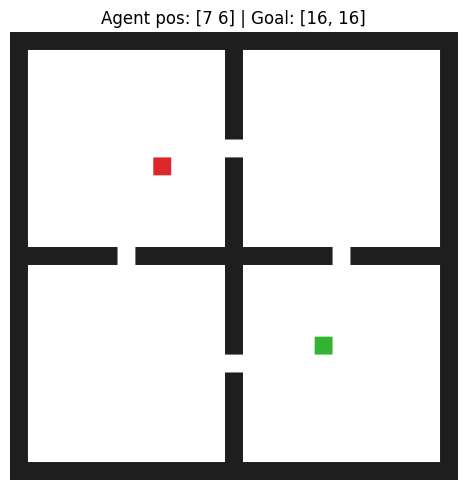

In [71]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# --- paste your class definitions above this line ---

env_base = FourRoomsGridWorld(render_mode="rgb_array")
env = FourRoomsGoalWrapper(env_base, goal_position=(16, 16))

obs, info = env.reset()
print("Start obs:", obs, "| Goal:", info["goal_position"])

frames = []
for _ in range(200):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    frame = env.render()
    frames.append(frame)
    if terminated or truncated:
        break

# --- render a single static frame ---
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(frames[-1])
ax.set_title(f"Agent pos: {obs.astype(int)} | Goal: {info['goal_position']}")
ax.axis("off")
plt.tight_layout()

### 4. The implementation of A Single Goal is All you Need.

###  $\phi(s,a)$

In [30]:
# Now here is the NN to train the sampled batch data from the replay buffer, the goal is to learn a dynamics model that predicts s_next from (s,a) pairs.

import torch.nn as nn
import torch.optim as optim 
import torch.nn.functional as F

class StateActionRepresentationModel(nn.Module): # a simple MLP that takes in (s,a) and predicts s_next, use hidden_layers to control the depth of the MLP, and hidden_dim to control the width of the MLP

    def __init__(self, obs_dim, action_dim, hidden_dim=256, output_dim=64, inner_layers=2,normalise=False): # A single goal paper specifies no normalisation
        super().__init__()
        self.fc1 = nn.Linear(obs_dim + action_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(inner_layers)])
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        self.normalise = normalise

    def forward(self, x):
        x = F.relu(self.fc1(x))
        for layer in self.hidden_layers:
            x = F.relu(layer(x))
        x = self.fc_out(x)
        if self.normalise: # if normalise is True, then we normalise the output to have unit norm, this can help with training stability and convergence, especially when using MSE loss, as it prevents the model from producing arbitrarily large outputs
            x = F.normalize(x, dim=-1)
        return x


 ### $\psi(g)$

In [31]:
class GoalRepresentationModel(nn.Module): # symmetric counterpart to StateActionRepresentationModel — maps a future/goal state sf to an embedding ψ(sf)

    def __init__(self, obs_dim, hidden_dim=256, inner_layers=2, output_dim=64, normalise=False): # same architecture choices as phi to keep the embedding space consistent
        super().__init__()
        self.fc1 = nn.Linear(obs_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(inner_layers)])
        self.fc_out = nn.Linear(hidden_dim, output_dim) # output in the same embedding space as StateActionRepresentationModel so that the dot product phi(s,a)^T psi(sf) is well-defined
        self.normalise = normalise

    def forward(self, x):
        x = F.relu(self.fc1(x))
        for layer in self.hidden_layers:
            x = F.relu(layer(x))
        x = self.fc_out(x)
        if self.normalise: # paper specifies no normalisation, but we keep the flag for experimentation
            x = F.normalize(x, dim=-1)
        return x


### InfoNCE + LogSumExp Regularisation Loss Function (Equation 3)

In [32]:
def contrastive_loss(all_logits, temperature=1, reg_coef=0.01):

    labels = torch.arange(all_logits.size(0), device=all_logits.device)
    scaled_logits = all_logits / temperature
    infonce_loss = F.cross_entropy(scaled_logits, labels) # the first term of the loss

    logsumexp = torch.logsumexp(scaled_logits, dim=-1)
    reg_loss  = reg_coef * logsumexp.pow(2).mean()   # penalise large LogSumExp values (matches -0.01 * (...) in the maximisation objective)

    return infonce_loss + reg_loss  # minimise this to maximise the paper's contrastive objective


In [33]:
MIN_STD = 1e-6
LOG_STD_MIN = float(np.log(MIN_STD))
LOG_STD_MAX =  2

class GoalConditionedActor(nn.Module): # goal-conditioned policy pi(a | s, g) — takes (s, g) and outputs a Gaussian action distribution

    def __init__(self, obs_dim, action_dim, hidden_dim=256, inner_layers=2):
        super().__init__()
        self.fc1 = nn.Linear(obs_dim * 2, hidden_dim)  # concatenate state s and goal g as input
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(inner_layers)])
        self.fc_mean    = nn.Linear(hidden_dim, action_dim)   # output the mean of the action distribution
        self.log_std_fc = nn.Linear(hidden_dim, action_dim)   # state-dependent log-std head

    def forward(self, obs, goal):
        x = torch.cat([obs, goal], dim=-1)  # (B, obs_dim * 2)
        x = F.relu(self.fc1(x))
        for layer in self.hidden_layers:
            x = F.relu(layer(x))
        mean    = self.fc_mean(x)  # (B, action_dim)
        log_std = self.log_std_fc(x).clamp(LOG_STD_MIN, LOG_STD_MAX)  # (B, action_dim)
        return mean, log_std

    def sample_action(self, obs, goal):
        mean, log_std = self.forward(obs, goal)
        std  = log_std.exp().clamp_min(MIN_STD)
        dist = torch.distributions.Normal(mean, std)

        # Reparameterised sample
        x_t    = dist.rsample()

        # Squash through tanh so actions always lie in (-1, 1)
        action = torch.tanh(x_t)

        # Correct log-prob for the tanh change-of-variables:
        # log π(a|s,g) = log N(x_t; μ, σ) - Σ log(1 - tanh²(x_t))
        log_prob = (dist.log_prob(x_t) - torch.log(1 - action.pow(2) + 1e-6)).sum(dim=-1, keepdim=True)  # (B, 1)
        entropy  = dist.entropy().sum(dim=-1, keepdim=True)  # (B, 1), H(pi(.|s,g))
        return action, log_prob, entropy



In [ ]:
# Rewrite version
# ── Imports for live visualisation ────────────────────────────────────────────
import matplotlib.pyplot as plt
from IPython.display import clear_output

# ── Hyperparameters ────────────────────────────────────────────────────────────
TOTAL_ENV_STEPS    = 20000   # total environment steps to collect
WARMUP_STEPS       = 10000    # random-action steps before any policy learning
BATCH_SIZE         = 256      # critic / actor batch size
SAMPLES_PER_INSERT = 64       # paper setting: each inserted transition is reused this many times on average
LR                 = 3e-4     # learning rate for critic + actor
INIT_ALPHA         = 0.1      # initial entropy weight before automatic tuning
ALPHA_LR           = 1e-4     # learning rate for entropy-weight tuning
TARGET_ENTROPY     = 0.0      # paper setting so it becomes deterministic
MIN_STD            = 1e-6     # paper setting: minimum actor std
SLIP_PROB          = 0.10     # slight transition stochasticity for learning robustness
LOG_INTERVAL       = 50       # refresh / print every this many gradient-update steps
MAX_HORIZON        = 500
NUMBER_OF_SGD_UPDATES_PER_STEP = 10
BUFFER_CAPACITY    = 100000
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"

# ── Single hard goal s* (Alg. 1, line 3) ──────────────────────────────────────
s_star = torch.tensor([22.0, 22.0], device=DEVICE, dtype=torch.float32)
s_star_batch = s_star.unsqueeze(0)
grad_step = 0

# ── Environment ───────────────────────────────────────────────────────────────
base_env = FourRoomsGridWorld(room_size=11, max_episode_steps=MAX_HORIZON)
env_train = FourRoomsGoalWrapper(
    base_env,
    goal_position=(22, 22),
    goal_reward=1.0,
    step_reward=0.0,
    slip_prob=SLIP_PROB,
)

obs_dim    = env_train.observation_space.shape[0]
action_dim = env_train.action_space.shape[0]
print (f"Observation space: {env_train.observation_space.shape[0]} | Action space: {env_train.action_space.shape[0]}")

replay_buffer = TrajectoryReplayBuffer(
    capacity=BUFFER_CAPACITY,
    obs_dim=obs_dim,
    action_dim=action_dim,
    device=DEVICE,
)
print(DEVICE)

phi_model = StateActionRepresentationModel(obs_dim, action_dim, hidden_dim=256, output_dim=64, inner_layers=2, normalise=False).to(DEVICE)
psi_model = GoalRepresentationModel(obs_dim, hidden_dim=256, output_dim=64, inner_layers=2, normalise=False).to(DEVICE)
actor     = GoalConditionedActor(obs_dim, action_dim, hidden_dim=256, inner_layers=2).to(DEVICE)

critic_optimizer = optim.Adam(list(phi_model.parameters()) + list(psi_model.parameters()), lr=LR)
actor_optimizer  = optim.Adam(actor.parameters(), lr=LR)
log_alpha        = torch.tensor(np.log(INIT_ALPHA), dtype=torch.float32, device=DEVICE, requires_grad=True)
alpha_optimizer  = optim.Adam([log_alpha], lr=ALPHA_LR)

# ── History buffers for visualisation ─────────────────────────────────────────
critic_loss_history     = []
actor_loss_history      = []
alpha_loss_history      = []
alpha_history           = []
ep_len_history          = []
entropy_history         = []
log_prob_history        = []
env_steps_at_update     = []
goal_similarity_history = []


# ── Helper: collect one episode into a dict ────────────────────────────────────
def collect_episode(env, policy_fn):
    """Run one episode. policy_fn(obs_tensor) -> action_np. Returns (ep_dict, ep_steps)."""
    obs_t, _ = env.reset()
    done = False
    ep = {k: [] for k in ["obs", "actions", "rewards", "next_obs", "terminated", "truncated"]}
    while not done:
        action_np = policy_fn(obs_t)
        next_obs_t, reward, term, trunc, _ = env.step(action_np)
        ep["obs"].append(obs_t.astype(np.float32))
        ep["actions"].append(action_np.astype(np.float32))
        ep["rewards"].append(np.float32(reward))
        ep["next_obs"].append(next_obs_t.astype(np.float32))
        ep["terminated"].append(np.float32(term))
        ep["truncated"].append(np.float32(trunc))
        obs_t = next_obs_t
        done  = term or trunc
    return ep, len(ep["obs"])


def random_policy(obs_t):
    return env_train.action_space.sample()

# ── Collect one trajectory using pi(a | s, g = s*) ───────────────────
def actor_policy(obs_t):
    obs_tensor = torch.tensor(obs_t, dtype=torch.float32, device=DEVICE).unsqueeze(0)

    with torch.no_grad():
        action, _, _ = actor.sample_action(obs_tensor, s_star_batch)
    action_np = action.squeeze(0).cpu().numpy()
    return action_np


total_env_steps = 0
print(f"Warmup: collecting {WARMUP_STEPS:,} random-action steps …")

while total_env_steps < WARMUP_STEPS:

    ep, ep_steps = collect_episode(env_train, random_policy)
    replay_buffer.add_episode(ep)
    total_env_steps += ep_steps


print(f"Warmup done.  Buffer size: {replay_buffer.size:,} transitions  "f"({total_env_steps:,} env steps collected).")

# main training phase with actor policy
while total_env_steps < TOTAL_ENV_STEPS:


    ep, ep_steps = collect_episode(env_train, actor_policy)
    replay_buffer.add_episode(ep)
    total_env_steps += ep_steps

    num_updates = int(NUMBER_OF_SGD_UPDATES_PER_STEP * ep_steps)

    for update in range(num_updates):

        grad_step += 1

        # Pair up positive states
        batch = replay_buffer.sample_future_goal_batch(BATCH_SIZE)
        obs = batch["obs"]
        actions = batch["actions"]
        goals = batch["goals"]

        # Now feed the state-action pair into the phi model, and its future state into the psi model
        phi_sa = phi_model(torch.cat([obs, actions], dim=-1))
        psi_g = psi_model(goals)

        logits = (phi_sa @ psi_g.T)

        critic_loss = contrastive_loss(logits)

        critic_optimizer.zero_grad()
        critic_loss.backward()
        critic_optimizer.step()

        with torch.no_grad():
            psi_sstar = psi_model(s_star.unsqueeze(0).expand(BATCH_SIZE, -1))
            goal_sim  = (phi_sa.detach() * psi_sstar).sum(dim=-1).mean().item()

        goal_similarity_history.append(goal_sim)

        def log_q(phi_sa, psi_g):
            return (phi_sa * psi_g).sum(dim=-1)

        perm = torch.randperm(BATCH_SIZE, device=DEVICE)
        goals_shuf = goals[perm]
        obs_aug   = torch.cat([obs, obs],   dim=0)
        goals_aug = torch.cat([goals, goals_shuf], dim=0)


        # Actor update - uses the same obs and goals as the critic update
        action_sampled, log_prob, _ = actor.sample_action(obs_aug, goals_aug)

        phi_sa_act = phi_model(torch.cat([obs_aug, action_sampled], dim=-1))
        psi_g_act  = psi_model(goals_aug)
        q_value = log_q(phi_sa_act, psi_g_act)
        entropy_batch = (-log_prob).mean()
        alpha_detached = log_alpha.exp().detach()

        actor_loss = - ((q_value + alpha_detached * entropy_batch).mean())

        actor_optimizer.zero_grad()
        actor_loss.backward()
        actor_optimizer.step()

        # Now alpha loss
        alpha = log_alpha.exp()
        alpha_loss = (alpha * ( -log_prob.detach() - TARGET_ENTROPY )).mean()

        alpha_optimizer.zero_grad()
        alpha_loss.backward()
        alpha_optimizer.step()


        # ── Record metrics ────────────────────────────────────────────────
    critic_loss_history.append(critic_loss.item())
    actor_loss_history.append(actor_loss.item())
    alpha_loss_history.append(alpha_loss.item())
    alpha_history.append(alpha.item())
    ep_len_history.append(ep_steps)
    entropy_history.append(entropy_batch.detach().mean().item())
    log_prob_history.append(log_prob.detach().mean().item())
    env_steps_at_update.append(total_env_steps)

    # ── Live plot every LOG_INTERVAL gradient steps ───────────────────
    if grad_step % LOG_INTERVAL == 0:
        print(f"GradStep {grad_step:>5} | env_steps: {total_env_steps:>7,} | ep_len: {ep_steps:>3} | "
                f"critic_loss: {critic_loss.item():.4f} | "
                f"actor_loss: {actor_loss.item():.4f} | alpha: {alpha.item():.6f} | goal_sim: {goal_sim:.4f}")

        clear_output(wait=True)
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
        axes = axes.flatten()

        axes[0].plot(env_steps_at_update, critic_loss_history, color='steelblue')
        axes[0].set_title("Critic loss (contrastive)")
        axes[0].set_xlabel("Env steps")
        axes[0].set_ylabel("Loss")

        axes[1].plot(env_steps_at_update, actor_loss_history, color='darkorange')
        axes[1].set_title("Actor loss")
        axes[1].set_xlabel("Env steps")
        axes[1].set_ylabel("Loss")

        axes[2].plot(env_steps_at_update, ep_len_history, color='seagreen')
        axes[2].axhline(MAX_HORIZON, color='gray', linestyle='--', linewidth=0.8, label='max horizon')
        axes[2].set_title("Episode length")
        axes[2].set_xlabel("Env steps")
        axes[2].set_ylabel("Steps")
        axes[2].legend()

        axes[3].plot(env_steps_at_update, alpha_loss_history, color='mediumpurple')
        axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.8)
        axes[3].set_title("Alpha loss")
        axes[3].set_xlabel("Env steps")
        axes[3].set_ylabel("Loss")

        plt.suptitle(f"Training progress — {total_env_steps:,} / {TOTAL_ENV_STEPS:,} env steps", fontsize=12)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

env_train.close()
print("Training complete!")
print(f"Total env steps: {total_env_steps:,} | Online gradient updates: {grad_step:,}")
print(f"Replay buffer size: {replay_buffer.stats()['size']:,}")
print(f"Final alpha: {log_alpha.exp().item():.6f} | Final entropy: {entropy_batch.detach().mean().item():.1f}")


Observation space: Box(0.0, 22.0, (2,), float32) | Action space: Box(-1.0, 1.0, (2,), float32)
mps
Warmup: collecting 10,000 random-action steps …
Warmup done.  Buffer size: 10,000 transitions  (10,000 env steps collected).


KeyboardInterrupt: 

### 5. Post-training summary plots


### 5a. Diagnostic: Network I/O distributions & positive/negative batch example

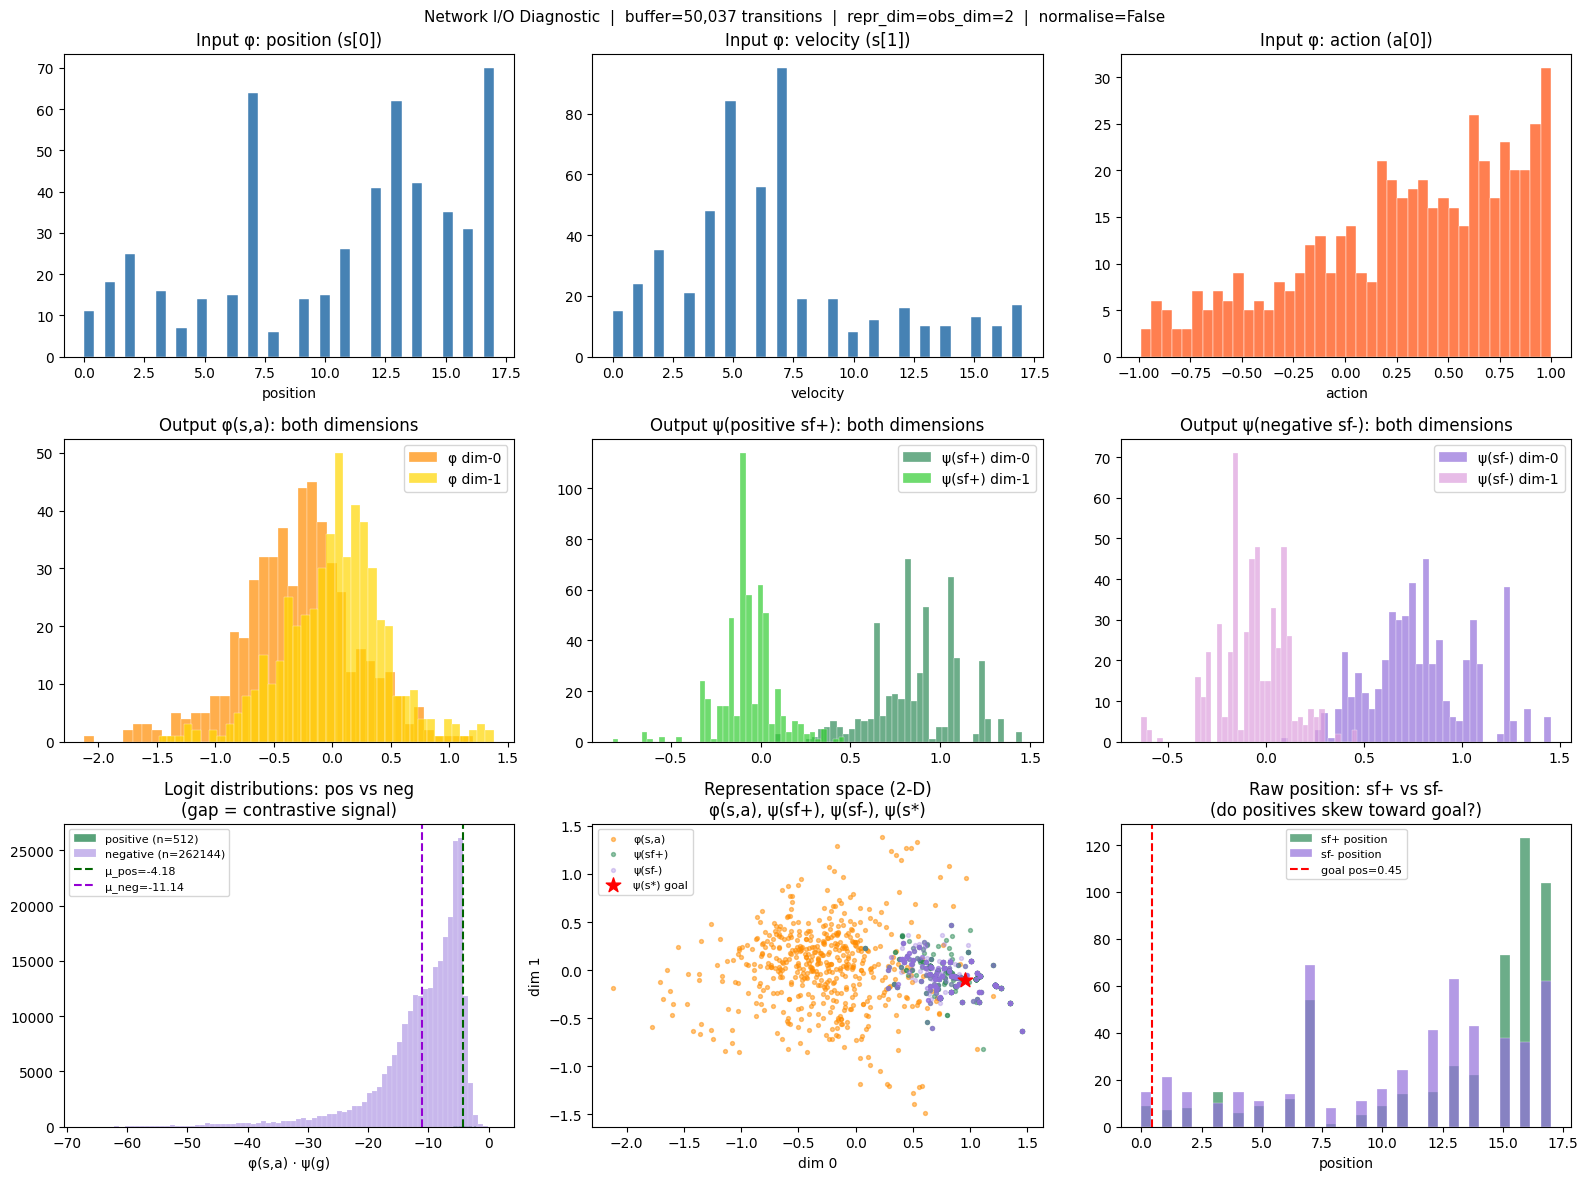


Summary statistics:
  φ(s,a) output  — mean: 0.060  std: 0.773  min: -4.750  max: 10.507
  ψ(sf+)  output  — mean: -0.103  std: 0.719  min: -4.988  max: 3.088
  ψ(sf-)  output  — mean: -0.103  std: 0.704  min: -4.421  max: 2.929
  pos logits      — mean: -4.179  std: 1.387
  neg logits      — mean: -11.138  std: 7.706
  contrastive gap (μ_pos - μ_neg): 6.960  (positive = good)


In [43]:
# ── Diagnostic: visualise network inputs, outputs, and one contrastive batch ──────
# Run this cell after training (phi_model, psi_model, replay_buffer must exist).
#
# Panel layout:
#   Row 1: distributions of raw network inputs  (state, action, goal)
#   Row 2: distributions of network outputs φ(s,a) and ψ(g)
#   Row 3: concrete single-batch example — pos logit vs neg logits distribution
#          + scatter of φ and ψ in 2-D representation space

import matplotlib.pyplot as plt
import numpy as np
import torch

_DIAG_B = 512   # batch size used for diagnostics
phi_model.eval()
psi_model.eval()

with torch.no_grad():
    # ── Sample a batch with positive future goals ─────────────────────────
    dbatch   = replay_buffer.sample_future_goal_batch(_DIAG_B)
    d_obs    = dbatch["obs"]      # (B, 2)  [position, velocity]
    d_act    = dbatch["actions"]  # (B, 1)  action
    d_goals  = dbatch["goals"]    # (B, 2)  positive future state sf+
    d_neg    = replay_buffer.sample_negative_future_goals(_DIAG_B)  # (B, 2) negatives

    # ── Network outputs ───────────────────────────────────────────────────
    d_phi    = phi_model(torch.cat([d_obs, d_act], dim=-1))  # (B, 2)
    d_psi_p  = psi_model(d_goals)    # (B, 2)  positive goal repr
    d_psi_n  = psi_model(d_neg)      # (B, 2)  negative goal repr

    # ── Logit distributions ───────────────────────────────────────────────
    pos_logits = (d_phi * d_psi_p).sum(dim=-1).cpu().numpy()      # (B,) diagonal
    neg_logits = (d_phi @ d_psi_n.T).cpu().numpy().flatten()      # (B*B,) all cross

    d_obs_np   = d_obs.cpu().numpy()
    d_act_np   = d_act.cpu().numpy()
    d_goals_np = d_goals.cpu().numpy()
    d_neg_np   = d_neg.cpu().numpy()
    d_phi_np   = d_phi.cpu().numpy()
    d_psi_p_np = d_psi_p.cpu().numpy()
    d_psi_n_np = d_psi_n.cpu().numpy()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

# ── Row 0: input distributions ────────────────────────────────────────────────
axes[0, 0].hist(d_obs_np[:, 0], bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0, 0].set_title('Input φ: position (s[0])')
axes[0, 0].set_xlabel('position')

axes[0, 1].hist(d_obs_np[:, 1], bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0, 1].set_title('Input φ: velocity (s[1])')
axes[0, 1].set_xlabel('velocity')

axes[0, 2].hist(d_act_np[:, 0], bins=40, color='coral', edgecolor='white', linewidth=0.3)
axes[0, 2].set_title('Input φ: action (a[0])')
axes[0, 2].set_xlabel('action')

# ── Row 1: network output distributions ───────────────────────────────────────
axes[1, 0].hist(d_phi_np[:, 0], bins=40, color='darkorange', edgecolor='white', linewidth=0.3, label='φ dim-0', alpha=0.7)
axes[1, 0].hist(d_phi_np[:, 1], bins=40, color='gold',       edgecolor='white', linewidth=0.3, label='φ dim-1', alpha=0.7)
axes[1, 0].set_title('Output φ(s,a): both dimensions')
axes[1, 0].legend()

axes[1, 1].hist(d_psi_p_np[:, 0], bins=40, color='seagreen',    edgecolor='white', linewidth=0.3, label='ψ(sf+) dim-0', alpha=0.7)
axes[1, 1].hist(d_psi_p_np[:, 1], bins=40, color='limegreen',   edgecolor='white', linewidth=0.3, label='ψ(sf+) dim-1', alpha=0.7)
axes[1, 1].set_title('Output ψ(positive sf+): both dimensions')
axes[1, 1].legend()

axes[1, 2].hist(d_psi_n_np[:, 0], bins=40, color='mediumpurple', edgecolor='white', linewidth=0.3, label='ψ(sf-) dim-0', alpha=0.7)
axes[1, 2].hist(d_psi_n_np[:, 1], bins=40, color='plum',         edgecolor='white', linewidth=0.3, label='ψ(sf-) dim-1', alpha=0.7)
axes[1, 2].set_title('Output ψ(negative sf-): both dimensions')
axes[1, 2].legend()

# ── Row 2: logit distributions + 2-D scatter ──────────────────────────────────
axes[2, 0].hist(pos_logits, bins=40, color='seagreen',    edgecolor='white', linewidth=0.3, label=f'positive (n={len(pos_logits)})', alpha=0.8)
axes[2, 0].hist(neg_logits, bins=80, color='mediumpurple', edgecolor='white', linewidth=0.2, label=f'negative (n={len(neg_logits)})', alpha=0.5)
axes[2, 0].axvline(np.mean(pos_logits), color='darkgreen',  linestyle='--', linewidth=1.5, label=f'μ_pos={np.mean(pos_logits):.2f}')
axes[2, 0].axvline(np.mean(neg_logits), color='darkviolet', linestyle='--', linewidth=1.5, label=f'μ_neg={np.mean(neg_logits):.2f}')
axes[2, 0].set_title('Logit distributions: pos vs neg\n(gap = contrastive signal)')
axes[2, 0].set_xlabel('φ(s,a) · ψ(g)')
axes[2, 0].legend(fontsize=8)

# 2-D scatter of φ and ψ in representation space
sc_phi = axes[2, 1].scatter(d_phi_np[:, 0],   d_phi_np[:, 1],   c='darkorange',    s=8, alpha=0.5, label='φ(s,a)')
sc_psp = axes[2, 1].scatter(d_psi_p_np[:, 0], d_psi_p_np[:, 1], c='seagreen',      s=8, alpha=0.5, label='ψ(sf+)')
sc_psn = axes[2, 1].scatter(d_psi_n_np[:, 0], d_psi_n_np[:, 1], c='mediumpurple',  s=8, alpha=0.3, label='ψ(sf-)')
# Mark s* goal
with torch.no_grad():
    psi_star_np = psi_model(s_star.unsqueeze(0)).cpu().numpy()
axes[2, 1].scatter(psi_star_np[0, 0], psi_star_np[0, 1], c='red', s=120, marker='*', zorder=5, label='ψ(s*) goal')
axes[2, 1].set_title('Representation space (2-D)\nφ(s,a), ψ(sf+), ψ(sf-), ψ(s*)')
axes[2, 1].set_xlabel('dim 0')
axes[2, 1].set_ylabel('dim 1')
axes[2, 1].legend(fontsize=8)

# Positive goal (sf+) input distribution vs negative goal (sf-) input distribution
axes[2, 2].hist(d_goals_np[:, 0], bins=40, color='seagreen',    edgecolor='white', linewidth=0.3, label='sf+ position', alpha=0.7)
axes[2, 2].hist(d_neg_np[:, 0],   bins=40, color='mediumpurple', edgecolor='white', linewidth=0.3, label='sf- position', alpha=0.7)
axes[2, 2].axvline(0.45, color='red', linestyle='--', linewidth=1.5, label='goal pos=0.45')
axes[2, 2].set_title('Raw position: sf+ vs sf-\n(do positives skew toward goal?)')
axes[2, 2].set_xlabel('position')
axes[2, 2].legend(fontsize=8)

plt.suptitle(
    f'Network I/O Diagnostic  |  buffer={replay_buffer.size:,} transitions  |  '
    f'repr_dim=obs_dim={obs_dim}  |  normalise={phi_model.normalise}',
    fontsize=11
)
plt.tight_layout()
plt.savefig('/tmp/network_io_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

phi_model.train()
psi_model.train()

print(f'\nSummary statistics:')
print(f'  φ(s,a) output  — mean: {d_phi_np.mean():.3f}  std: {d_phi_np.std():.3f}  min: {d_phi_np.min():.3f}  max: {d_phi_np.max():.3f}')
print(f'  ψ(sf+)  output  — mean: {d_psi_p_np.mean():.3f}  std: {d_psi_p_np.std():.3f}  min: {d_psi_p_np.min():.3f}  max: {d_psi_p_np.max():.3f}')
print(f'  ψ(sf-)  output  — mean: {d_psi_n_np.mean():.3f}  std: {d_psi_n_np.std():.3f}  min: {d_psi_n_np.min():.3f}  max: {d_psi_n_np.max():.3f}')
print(f'  pos logits      — mean: {pos_logits.mean():.3f}  std: {pos_logits.std():.3f}')
print(f'  neg logits      — mean: {neg_logits.mean():.3f}  std: {neg_logits.std():.3f}')
print(f'  contrastive gap (μ_pos - μ_neg): {pos_logits.mean() - neg_logits.mean():.3f}  (positive = good)')


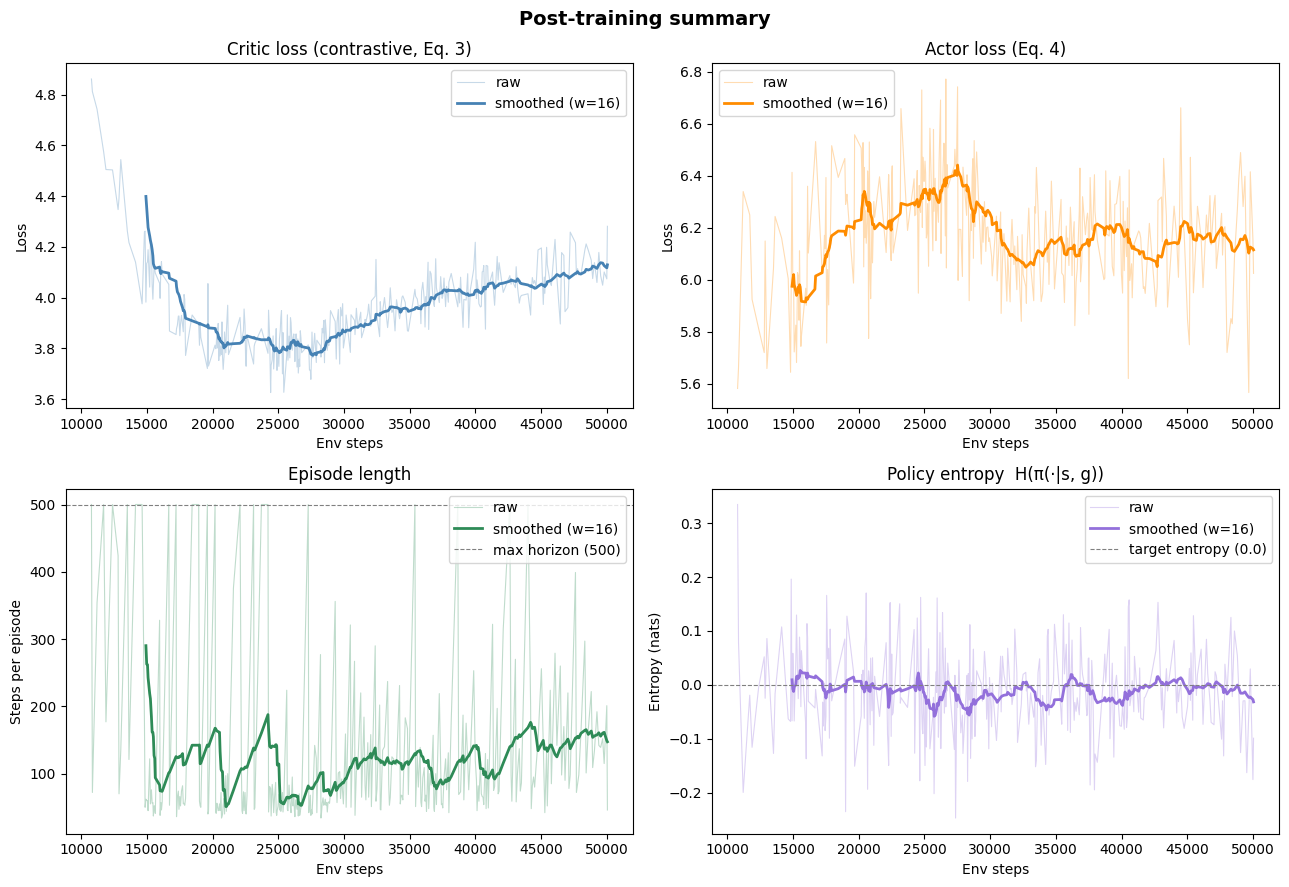

In [44]:
# ── Post-training summary: four-panel static plot ─────────────────────────────
# Smooth a 1-D list with a simple rolling window mean to reduce noise in the curves.
def smooth(values, window=10):
    if len(values) < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode='valid')

steps_full = np.asarray(env_steps_at_update)
smooth_w   = max(1, len(steps_full) // 20) if len(steps_full) > 0 else 1

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# ─ Critic loss ─
ax = axes[0, 0]
ax.plot(steps_full, critic_loss_history, color='steelblue', alpha=0.3, linewidth=0.8, label='raw')
ax.plot(steps_full[smooth_w - 1:], smooth(critic_loss_history, smooth_w),
        color='steelblue', linewidth=2, label=f'smoothed (w={smooth_w})')
ax.set_title("Critic loss (contrastive, Eq. 3)")
ax.set_xlabel("Env steps")
ax.set_ylabel("Loss")
ax.legend()

# ─ Actor loss ─
ax = axes[0, 1]
ax.plot(steps_full, actor_loss_history, color='darkorange', alpha=0.3, linewidth=0.8, label='raw')
ax.plot(steps_full[smooth_w - 1:], smooth(actor_loss_history, smooth_w),
        color='darkorange', linewidth=2, label=f'smoothed (w={smooth_w})')
ax.set_title("Actor loss (Eq. 4)")
ax.set_xlabel("Env steps")
ax.set_ylabel("Loss")
ax.legend()

# ─ Episode length ─
ax = axes[1, 0]
ax.plot(steps_full, ep_len_history, color='seagreen', alpha=0.3, linewidth=0.8, label='raw')
ax.plot(steps_full[smooth_w - 1:], smooth(ep_len_history, smooth_w),
        color='seagreen', linewidth=2, label=f'smoothed (w={smooth_w})')
ax.axhline(MAX_HORIZON, color='gray', linestyle='--', linewidth=0.8, label=f'max horizon ({MAX_HORIZON})')
ax.set_title("Episode length")
ax.set_xlabel("Env steps")
ax.set_ylabel("Steps per episode")
ax.legend()
# A shorter episode that terminates (rather than truncates) means the agent reached the goal.

# ─ Policy entropy ─
ax = axes[1, 1]
ax.plot(steps_full, entropy_history, color='mediumpurple', alpha=0.3, linewidth=0.8, label='raw')
ax.plot(steps_full[smooth_w - 1:], smooth(entropy_history, smooth_w),
        color='mediumpurple', linewidth=2, label=f'smoothed (w={smooth_w})')
ax.axhline(TARGET_ENTROPY, color='gray', linestyle='--', linewidth=0.8, label=f'target entropy ({TARGET_ENTROPY:.1f})')
ax.set_title("Policy entropy  H(π(·|s, g))")
ax.set_xlabel("Env steps")
ax.set_ylabel("Entropy (nats)")
ax.legend()
# With target entropy = 0, the policy entropy should trend downward toward zero over training.

plt.suptitle("Post-training summary", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



### 6. State-coverage heatmap


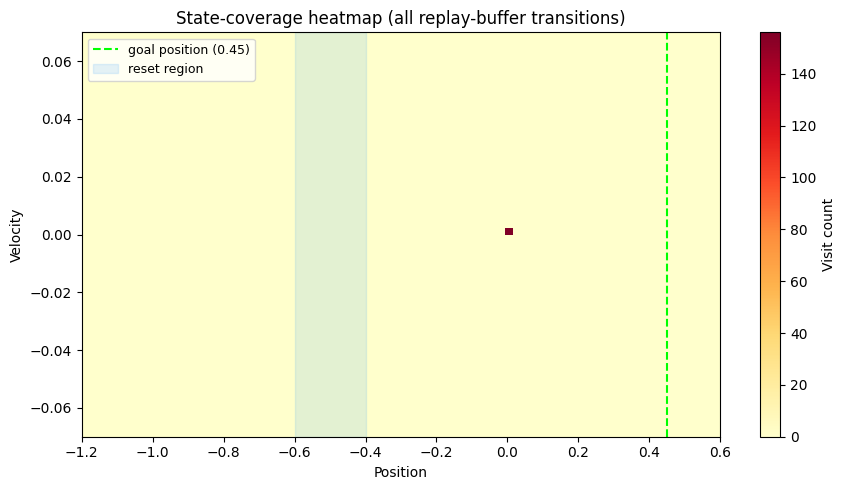

Plotted 50,037 transitions.


In [45]:
# ── State-coverage heatmap ─────────────────────────────────────────────────────
# Visualise WHERE in (position, velocity) space the agent has been during training.
# Dense regions → well explored; sparse regions → rarely visited.
# If the goal position (0.45) is never reached, the right-hand side will be empty.

all_states = replay_buffer.obs[: replay_buffer.size]   # (N, 2) numpy array

positions  = all_states[:, 0]   # x-axis: car position ∈ [-1.2, 0.6]
velocities = all_states[:, 1]   # y-axis: car velocity ∈ [-0.07, 0.07]

fig, ax = plt.subplots(figsize=(9, 5))

h = ax.hist2d(
    positions, velocities,
    bins=[80, 60],
    range=[[-1.2, 0.6], [-0.07, 0.07]],
    cmap='YlOrRd',
    density=False,
)
cbar = plt.colorbar(h[3], ax=ax)
cbar.set_label("Visit count")

# Goal position marker
ax.axvline(0.45, color='lime', linewidth=1.5, linestyle='--', label='goal position (0.45)')

# Starting region: env resets position uniformly in [-0.6, -0.4]
ax.axvspan(-0.6, -0.4, alpha=0.12, color='dodgerblue', label='reset region')

ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.set_title("State-coverage heatmap (all replay-buffer transitions)")
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()
print(f"Plotted {replay_buffer.size:,} transitions.")


### 7. Final policy rollout — render learned behaviour


  Rollout 1: 366 steps | total reward: 1.00 | reached goal: True
  Rollout 2: 334 steps | total reward: 1.00 | reached goal: True
  Rollout 3: 500 steps | total reward: 0.00 | reached goal: False
  Rollout 4: 183 steps | total reward: 1.00 | reached goal: True
  Rollout 5: 163 steps | total reward: 1.00 | reached goal: True
  Rollout 6: 500 steps | total reward: 0.00 | reached goal: False
  Rollout 7: 500 steps | total reward: 0.00 | reached goal: False
  Rollout 8: 57 steps | total reward: 1.00 | reached goal: True
  Rollout 9: 500 steps | total reward: 0.00 | reached goal: False
  Rollout 10: 500 steps | total reward: 0.00 | reached goal: False
  Rollout 11: 33 steps | total reward: 1.00 | reached goal: True
  Rollout 12: 500 steps | total reward: 0.00 | reached goal: False
  Rollout 13: 500 steps | total reward: 0.00 | reached goal: False
  Rollout 14: 500 steps | total reward: 0.00 | reached goal: False
  Rollout 15: 309 steps | total reward: 1.00 | reached goal: True
  Rollout 16:

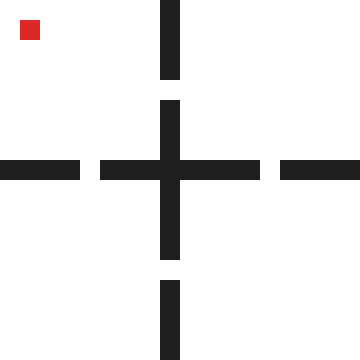

In [46]:
from IPython.display import Image
import imageio.v2 as imageio

RENDER_EPISODES = 20
RENDER_FPS      = 8

env_render = FourRoomsGridWorld(room_size=9, render_mode="rgb_array", max_episode_steps=MAX_HORIZON)
env_render = FourRoomsGoalWrapper(
    env_render,
    goal_position=(16, 16),
    goal_reward=1.0,
    step_reward=0.0,
    slip_prob=SLIP_PROB,
)

phi_model.eval()
psi_model.eval()
actor.eval()

all_frames = []
ep_rewards = []
trajectories = []

s_star_render = s_star.unsqueeze(0)

def deterministic_action(obs_tensor, goal_tensor):
    with torch.no_grad():
        mean, _ = actor(obs_tensor, goal_tensor)
        action = torch.tanh(mean)
    return action

for ep_i in range(RENDER_EPISODES):
    obs_r, _ = env_render.reset()
    done_r = False
    ep_rew = 0.0
    trajectory = [obs_r.copy()]

    while not done_r:
        frame = env_render.render()
        all_frames.append(frame)

        obs_tensor_r = torch.tensor(obs_r, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        action_r = deterministic_action(obs_tensor_r, s_star_render)
        action_r_np = action_r.squeeze(0).cpu().numpy()
        action_r_np = np.clip(action_r_np, env_render.action_space.low, env_render.action_space.high)

        obs_r, rew_r, term_r, trunc_r, _ = env_render.step(action_r_np)
        ep_rew += rew_r
        trajectory.append(obs_r.copy())
        done_r = term_r or trunc_r

    ep_rewards.append(ep_rew)
    trajectories.append(np.asarray(trajectory, dtype=np.float32))
    reached = np.array_equal(trajectory[-1].astype(np.int32), np.array([16, 16], dtype=np.int32))
    print(f"  Rollout {ep_i+1}: {len(trajectory)-1} steps | total reward: {ep_rew:.2f} | reached goal: {reached}")

env_render.close()
phi_model.train()
psi_model.train()
actor.train()

gif_path = "/tmp/policy_rollout.gif"
imageio.mimsave(gif_path, all_frames, fps=RENDER_FPS, loop=0)
print(f"\nSaved GIF ({len(all_frames)} frames) → {gif_path}")

goal_xy = np.array([16, 16], dtype=np.int32)
successes = [np.array_equal(path[-1].astype(np.int32), goal_xy) for path in trajectories]
success_rate = np.mean(successes) if successes else 0.0
avg_return   = np.mean(ep_rewards) if ep_rewards else 0.0
std_return   = np.std(ep_rewards) if ep_rewards else 0.0

print(f"Success rate (deterministic policy): {success_rate:.2%} over {RENDER_EPISODES} episodes")
print(f"Average return: {avg_return:.2f} ± {std_return:.2f}")

Image(gif_path)


### Q table and alpha-entropy plot

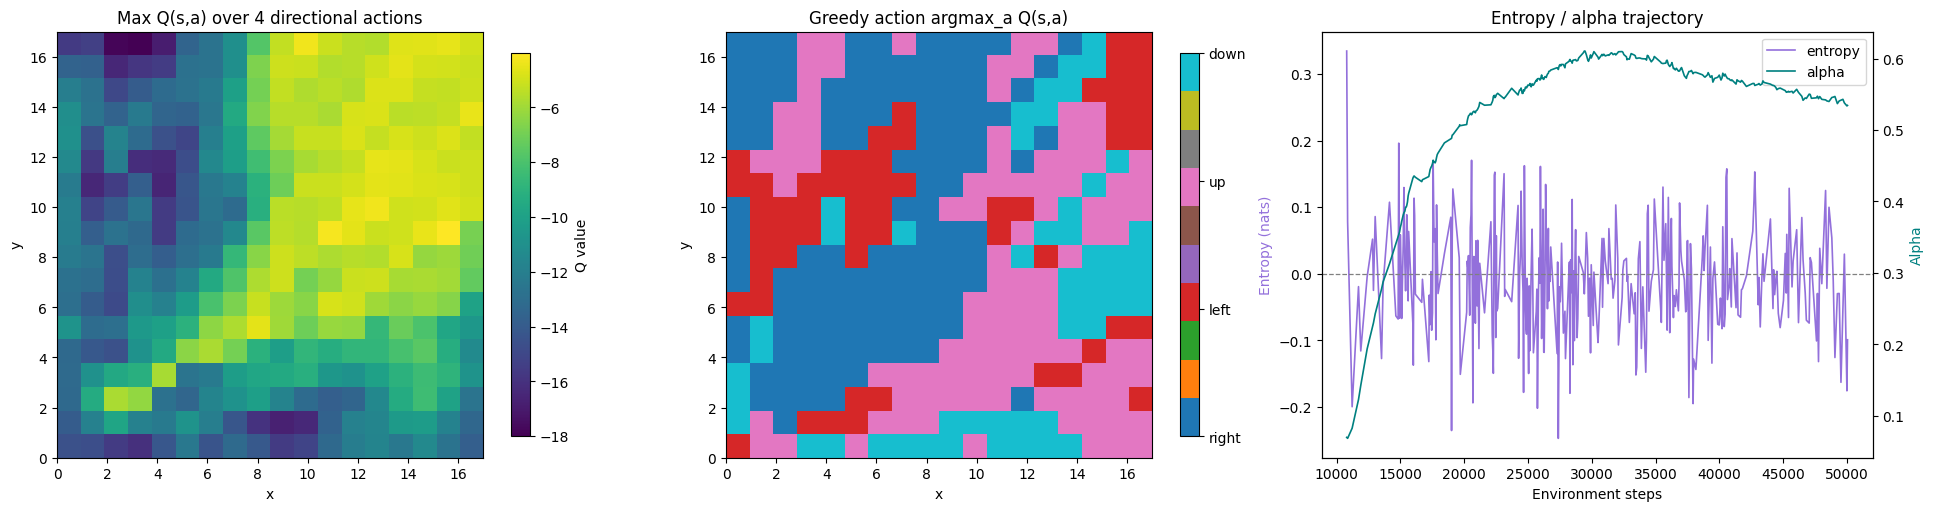

In [47]:
# ── Q-value table-style visualisation + alpha/entropy diagnostic ───────────────
import numpy as np
import matplotlib.pyplot as plt
import torch

phi_model.eval()
psi_model.eval()

obs_low  = env_train.observation_space.low.astype(np.float32)
obs_high = env_train.observation_space.high.astype(np.float32)

x_bins = np.linspace(obs_low[0], obs_high[0], 18, dtype=np.float32)
y_bins = np.linspace(obs_low[1], obs_high[1], 18, dtype=np.float32)
action_vectors = np.array([
    [1.0, 0.0],   # right
    [-1.0, 0.0],  # left
    [0.0, 1.0],   # up
    [0.0, -1.0],  # down
], dtype=np.float32)
action_names = ["right", "left", "up", "down"]

goal_embed = psi_model(s_star.unsqueeze(0)).detach()
q_best = np.zeros((len(y_bins), len(x_bins)), dtype=np.float32)
best_action_idx = np.zeros_like(q_best, dtype=np.int32)

with torch.no_grad():
    for yi, y in enumerate(y_bins):
        states_np = np.stack([x_bins, np.full_like(x_bins, y)], axis=1)
        states = torch.tensor(states_np, dtype=torch.float32, device=DEVICE)

        q_per_action = []
        for a_vec in action_vectors:
            a_batch = torch.tensor(np.repeat(a_vec[None, :], states.shape[0], axis=0), dtype=torch.float32, device=DEVICE)
            phi_sa = phi_model(torch.cat([states, a_batch], dim=-1))
            q_sa = (phi_sa * goal_embed.expand(states.shape[0], -1)).sum(dim=-1)
            q_per_action.append(q_sa.cpu().numpy())

        q_per_action = np.stack(q_per_action, axis=0)
        best_idx = np.argmax(q_per_action, axis=0)
        q_best[yi] = q_per_action[best_idx, np.arange(q_per_action.shape[1])]
        best_action_idx[yi] = best_idx

fig, axes = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)
extent = [x_bins.min(), x_bins.max(), y_bins.min(), y_bins.max()]

im0 = axes[0].imshow(q_best, origin='lower', aspect='equal', extent=extent, cmap='viridis')
axes[0].set_title('Max Q(s,a) over 4 directional actions')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
fig.colorbar(im0, ax=axes[0], shrink=0.9, label='Q value')

im1 = axes[1].imshow(best_action_idx, origin='lower', aspect='equal', extent=extent, cmap='tab10', vmin=0, vmax=3)
axes[1].set_title('Greedy action argmax_a Q(s,a)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
cbar = fig.colorbar(im1, ax=axes[1], shrink=0.9, ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels(action_names)

if len(entropy_history) and len(alpha_history):
    steps = np.array(env_steps_at_update, dtype=np.float32)
    axes[2].plot(steps, entropy_history, color='mediumpurple', linewidth=1.2, label='entropy')
    ax2 = axes[2].twinx()
    ax2.plot(steps, alpha_history, color='teal', linewidth=1.2, label='alpha')
    axes[2].axhline(TARGET_ENTROPY, color='gray', linestyle='--', linewidth=0.9)
    axes[2].set_title('Entropy / alpha trajectory')
    axes[2].set_xlabel('Environment steps')
    axes[2].set_ylabel('Entropy (nats)', color='mediumpurple')
    ax2.set_ylabel('Alpha', color='teal')

    h1, l1 = axes[2].get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    axes[2].legend(h1 + h2, l1 + l2, loc='upper right')
else:
    axes[2].text(0.5, 0.5, 'No alpha/entropy history found', ha='center', va='center')
    axes[2].set_axis_off()

plt.show()


## Transfer Evaluation

In [40]:
# Transfer evaluation with a different sparse goal location
TRANSFER_GOAL = (1, 16)
s_star_transfer = torch.tensor([float(TRANSFER_GOAL[0]), float(TRANSFER_GOAL[1])], device=DEVICE, dtype=torch.float32)


  Rollout 1: 500 steps | total reward: 0.00 | reached goal: False
  Rollout 2: 500 steps | total reward: 0.00 | reached goal: False
  Rollout 3: 500 steps | total reward: 0.00 | reached goal: False
  Rollout 4: 500 steps | total reward: 0.00 | reached goal: False
  Rollout 5: 500 steps | total reward: 0.00 | reached goal: False
  Rollout 6: 500 steps | total reward: 0.00 | reached goal: False
  Rollout 7: 500 steps | total reward: 0.00 | reached goal: False
  Rollout 8: 500 steps | total reward: 0.00 | reached goal: False
  Rollout 9: 500 steps | total reward: 0.00 | reached goal: False
  Rollout 10: 500 steps | total reward: 0.00 | reached goal: False
  Rollout 11: 500 steps | total reward: 0.00 | reached goal: False
  Rollout 12: 500 steps | total reward: 0.00 | reached goal: False
  Rollout 13: 500 steps | total reward: 0.00 | reached goal: False
  Rollout 14: 500 steps | total reward: 0.00 | reached goal: False
  Rollout 15: 500 steps | total reward: 0.00 | reached goal: False
  Ro

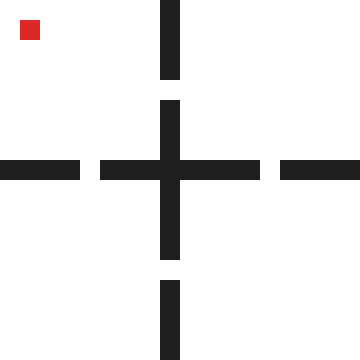

In [41]:
from IPython.display import Image
import imageio.v2 as imageio

RENDER_EPISODES = 20
RENDER_FPS      = 8

env_render = FourRoomsGridWorld(room_size=9, render_mode="rgb_array", max_episode_steps=MAX_HORIZON)
env_render = FourRoomsGoalWrapper(
    env_render,
    goal_position=TRANSFER_GOAL,
    goal_reward=1.0,
    step_reward=0.0,
    slip_prob=SLIP_PROB,
)

s_star_transfer_render = s_star_transfer.unsqueeze(0)

phi_model.eval()
psi_model.eval()
actor.eval()

all_frames = []
ep_rewards = []
trajectories = []

def deterministic_action(obs_tensor, goal_tensor):
    with torch.no_grad():
        mean, _ = actor(obs_tensor, goal_tensor)
        action = torch.tanh(mean)
    return action

for ep_i in range(RENDER_EPISODES):
    obs_r, _ = env_render.reset()
    done_r = False
    ep_rew = 0.0
    trajectory = [obs_r.copy()]

    while not done_r:
        frame = env_render.render()
        all_frames.append(frame)

        obs_tensor_r = torch.tensor(obs_r, dtype=torch.float32, device=DEVICE).unsqueeze(0)

        action_r = deterministic_action(obs_tensor_r, s_star_transfer_render)
        action_r_np = action_r.squeeze(0).cpu().numpy()
        action_r_np = np.clip(action_r_np, env_render.action_space.low, env_render.action_space.high)

        obs_r, rew_r, term_r, trunc_r, _ = env_render.step(action_r_np)
        ep_rew += rew_r
        trajectory.append(obs_r.copy())
        done_r = term_r or trunc_r

    ep_rewards.append(ep_rew)
    trajectories.append(np.asarray(trajectory, dtype=np.float32))
    reached = np.array_equal(trajectory[-1].astype(np.int32), np.array(TRANSFER_GOAL, dtype=np.int32))
    print(f"  Rollout {ep_i+1}: {len(trajectory)-1} steps | total reward: {ep_rew:.2f} | reached goal: {reached}")

env_render.close()
phi_model.train()
psi_model.train()
actor.train()

gif_path = "/tmp/policy_rollout_transfer_goal.gif"
imageio.mimsave(gif_path, all_frames, fps=RENDER_FPS, loop=0)
print(f"\nSaved GIF ({len(all_frames)} frames) → {gif_path}")

goal_xy = np.array(TRANSFER_GOAL, dtype=np.int32)
successes = [np.array_equal(path[-1].astype(np.int32), goal_xy) for path in trajectories]
success_rate = np.mean(successes) if successes else 0.0
avg_return   = np.mean(ep_rewards) if ep_rewards else 0.0
std_return   = np.std(ep_rewards) if ep_rewards else 0.0

print(f"Success rate (deterministic policy): {success_rate:.2%} over {RENDER_EPISODES} episodes")
print(f"Average return: {avg_return:.2f} ± {std_return:.2f}")

Image(gif_path)
